# 03 Uncertainty and Error Maps (Summary-Level)

This notebook links uncertainty-style signals to the failure taxonomy output from `01_failure_case_taxonomy.ipynb`.

Main goals:
- quantify uncertainty by failure type
- check how uncertainty relates to IoU / FP / FN
- export report-ready CSV tables and figures


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

def find_suite_dir(start: Path = Path.cwd()) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if path.name == 'explainability_suite':
            return path
        candidate = path / 'analysis' / 'explainability_suite'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find analysis/explainability_suite')

ROOT = find_suite_dir()
OUT_DIR = ROOT / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)
print('OUT_DIR =', OUT_DIR)


ROOT = /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite
OUT_DIR = /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs


In [2]:
files = sorted(OUT_DIR.glob('failure_taxonomy_*.csv'))
if not files:
    raise FileNotFoundError('No failure_taxonomy_*.csv found in outputs/.')

frames = []
for f in files:
    df = pd.read_csv(f)
    df['source_file'] = f.name
    if 'model_name' not in df.columns:
        model_guess = f.stem.replace('failure_taxonomy_', '')
        df['model_name'] = model_guess
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
print('Loaded rows:', len(all_df))
print('Columns:', list(all_df.columns))
all_df.head(5)


Loaded rows: 73
Columns: ['sample_id', 'gt_pixels', 'pred_pixels', 'tp_pixels', 'fp_pixels', 'fn_pixels', 'iou', 'f1', 'precision', 'recall', 'mean_prob_on_gt', 'mean_prob_on_fp', 'mean_uncertainty', 'image_brightness', 'fp_brightness', 'fn_brightness', 'image_edge_strength', 'fp_edge_strength', 'fn_edge_strength', 'fp_overlap_water_pixels', 'fp_overlap_leaching_pixels', 'fp_overlap_noncrack_ratio', 'pred_components', 'pred_largest_area', 'pred_max_elongation', 'gt_components', 'gt_largest_area', 'gt_max_elongation', 'candidate_failure_type', 'image_name', 'image_abs_path', 'raw_mask_path', 'decision_threshold', 'setting', 'model_name', 'source_file', 'review_target_type', 'human_failure_type', 'notes']


,sample_id,gt_pixels,pred_pixels,tp_pixels,fp_pixels,fn_pixels,iou,f1,precision,recall,...,image_name,image_abs_path,raw_mask_path,decision_threshold,setting,model_name,source_file,review_target_type,human_failure_type,notes
0,0,0,17,0,17,0,0.0,0.0,0.0,0.0,...,TB_Camera7_000012_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB,failure_taxonomy_Unet-resnet34-imagenet_Single...,NaN,NaN,NaN
1,1,0,0,0,0,0,0.0,0.0,0.0,0.0,...,TB_Camera3_001107_H.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB,failure_taxonomy_Unet-resnet34-imagenet_Single...,NaN,NaN,NaN
2,2,0,0,0,0,0,0.0,0.0,0.0,0.0,...,TB_Camera4_000334_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB,failure_taxonomy_Unet-resnet34-imagenet_Single...,NaN,NaN,NaN
3,3,0,0,0,0,0,0.0,0.0,0.0,0.0,...,TB_Camera5_000894_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB,failure_taxonomy_Unet-resnet34-imagenet_Single...,NaN,NaN,NaN
4,4,0,202,0,202,0,0.0,0.0,0.0,0.0,...,TB_Camera9_000558_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB,failure_taxonomy_Unet-resnet34-imagenet_Single...,NaN,NaN,NaN


In [3]:
# Normalize failure label column
label_col = 'candidate_failure_type' if 'candidate_failure_type' in all_df.columns else None
if label_col is None:
    all_df['failure_type'] = 'unknown'
else:
    all_df['failure_type'] = all_df[label_col].fillna('unknown').astype(str)

# Keep metrics we need
needed = [
    'model_name', 'setting', 'sample_id', 'image_name', 'failure_type',
    'iou', 'f1', 'precision', 'recall',
    'tp_pixels', 'fp_pixels', 'fn_pixels', 'pred_pixels', 'gt_pixels',
    'mean_prob_on_gt', 'mean_prob_on_fp', 'mean_uncertainty'
]
keep_cols = [c for c in needed if c in all_df.columns]
df = all_df[keep_cols].copy()

for c in ['iou','f1','precision','recall','mean_prob_on_gt','mean_prob_on_fp','mean_uncertainty','tp_pixels','fp_pixels','fn_pixels','pred_pixels','gt_pixels']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['failure_type'] = df['failure_type'].fillna('unknown')
df.head(3)


,model_name,setting,sample_id,image_name,failure_type,iou,f1,precision,recall,tp_pixels,fp_pixels,fn_pixels,pred_pixels,gt_pixels,mean_prob_on_gt,mean_prob_on_fp,mean_uncertainty
0,Unet-resnet34-imagenet_Single-TB,Single-TB,0,TB_Camera7_000012_E.png,mixed_or_unclear_failure,0.0,0.0,0.0,0.0,0,17,0,17,0,NaN,0.650414,0.053653
1,Unet-resnet34-imagenet_Single-TB,Single-TB,1,TB_Camera3_001107_H.png,mixed_or_unclear_failure,0.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,0.046942
2,Unet-resnet34-imagenet_Single-TB,Single-TB,2,TB_Camera4_000334_N.png,mixed_or_unclear_failure,0.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,0.027362


In [4]:
summary = (
    df.groupby(['model_name', 'failure_type'], dropna=False)
      .agg(
          n_samples=('sample_id', 'count'),
          mean_iou=('iou', 'mean'),
          mean_f1=('f1', 'mean'),
          mean_precision=('precision', 'mean'),
          mean_recall=('recall', 'mean'),
          mean_uncertainty=('mean_uncertainty', 'mean'),
          mean_prob_on_gt=('mean_prob_on_gt', 'mean'),
          mean_prob_on_fp=('mean_prob_on_fp', 'mean'),
          fp_pixels=('fp_pixels', 'sum'),
          fn_pixels=('fn_pixels', 'sum'),
      )
      .reset_index()
      .sort_values(['model_name', 'mean_uncertainty'], ascending=[True, False])
)

out_csv = OUT_DIR / 'uncertainty_by_failure_type.csv'
summary.to_csv(out_csv, index=False)
print('Saved:', out_csv)
summary.head(20)


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/uncertainty_by_failure_type.csv


,model_name,failure_type,n_samples,mean_iou,mean_f1,mean_precision,mean_recall,mean_uncertainty,mean_prob_on_gt,mean_prob_on_fp,fp_pixels,fn_pixels
17,Unet-resnet34-imagenet_Single-TB,mixed_or_unclear_failure,28,0.000000,0.000000,0.000000,0.000000,0.035184,0.004145,0.725904,532,227
0,Unet-resnet34-imagenet_Single-TB,fp_dark_shadow_candidate,1,0.000000,0.000000,0.000000,0.000000,0.028021,NaN,0.801783,180,0
13,Unet-resnet34-imagenet_Single-TB,missed_low_confidence_crack,6,0.084780,0.144181,0.346530,0.092637,0.027554,0.101250,0.772721,384,8290
10,Unet-resnet34-imagenet_Single-TB,"fragmented_or_thin_crack, fp_dark_shadow_candi...",2,0.695272,0.820248,0.836874,0.804270,0.026491,0.795148,0.904460,3686,4602
14,Unet-resnet34-imagenet_Single-TB,"missed_low_confidence_crack, fragmented_or_thi...",2,0.000000,0.000000,0.000000,0.000000,0.022001,0.001713,NaN,0,398
16,Unet-resnet34-imagenet_Single-TB,"missed_low_confidence_crack, fragmented_or_thi...",2,0.313761,0.477653,0.747065,0.351053,0.021138,0.345306,0.871111,474,2588
3,Unet-resnet34-imagenet_Single-TB,"fp_dark_shadow_candidate, fp_long_linear_struc...",3,0.000000,0.000000,0.000000,0.000000,0.019478,NaN,0.890457,1226,0
2,Unet-resnet34-imagenet_Single-TB,"fp_dark_shadow_candidate, fp_edge_or_seam_cand...",2,0.256625,0.408435,0.283513,0.730159,0.019458,0.717340,0.855797,930,136
8,Unet-resnet34-imagenet_Single-TB,fp_long_linear_structure_candidate,2,0.056020,0.100752,0.063810,0.239286,0.018481,0.472523,0.888552,909,73
5,Unet-resnet34-imagenet_Single-TB,"fp_dark_shadow_candidate, over_thick_or_overse...",1,0.379921,0.550642,0.476543,0.652027,0.017673,0.664056,0.875206,212,103


In [5]:
# Global uncertainty quantile analysis
q = df['mean_uncertainty'].quantile([0.2, 0.4, 0.6, 0.8]).values
bins = [-np.inf, *q, np.inf]
labels = ['Q1(low)', 'Q2', 'Q3', 'Q4', 'Q5(high)']
df['uncertainty_bin'] = pd.cut(df['mean_uncertainty'], bins=bins, labels=labels)

quant_summary = (
    df.groupby(['model_name', 'uncertainty_bin'], dropna=False)
      .agg(
          n_samples=('sample_id', 'count'),
          mean_iou=('iou', 'mean'),
          mean_f1=('f1', 'mean'),
          mean_precision=('precision', 'mean'),
          mean_recall=('recall', 'mean'),
          fp_pixels=('fp_pixels', 'sum'),
          fn_pixels=('fn_pixels', 'sum'),
      )
      .reset_index()
)

out_csv2 = OUT_DIR / 'uncertainty_quantile_performance.csv'
quant_summary.to_csv(out_csv2, index=False)
print('Saved:', out_csv2)
quant_summary


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/uncertainty_quantile_performance.csv


,model_name,uncertainty_bin,n_samples,mean_iou,mean_f1,mean_precision,mean_recall,fp_pixels,fn_pixels
0,Unet-resnet34-imagenet_Single-TB,Q1(low),15,0.273386,0.404274,0.363100,0.544616,10987,8077
1,Unet-resnet34-imagenet_Single-TB,Q2,15,0.257361,0.361135,0.396520,0.414503,6816,8811
2,Unet-resnet34-imagenet_Single-TB,Q3,14,0.089244,0.137230,0.178522,0.134421,1774,3962
3,Unet-resnet34-imagenet_Single-TB,Q4,14,0.148031,0.189823,0.171083,0.237973,6306,4991
4,Unet-resnet34-imagenet_Single-TB,Q5(high),15,0.000000,0.000000,0.000000,0.000000,180,1136


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/fig_uncertainty_vs_iou.png


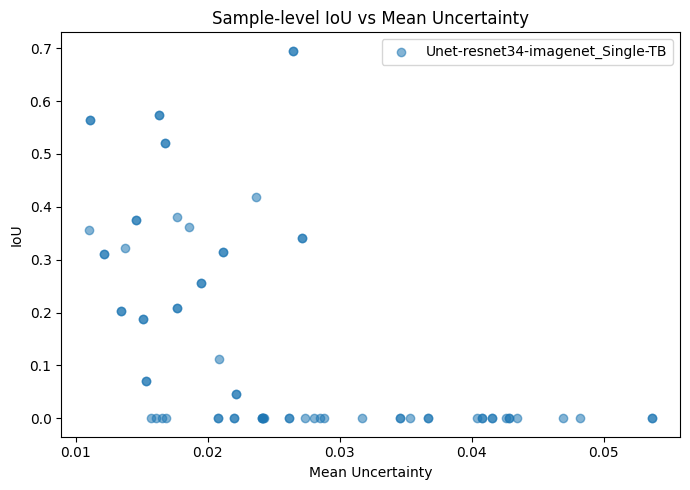

In [6]:
# Figure 1: uncertainty vs IoU
fig, ax = plt.subplots(figsize=(7, 5))
if sns is not None:
    sns.scatterplot(data=df, x='mean_uncertainty', y='iou', hue='model_name', alpha=0.55, ax=ax)
else:
    for m, g in df.groupby('model_name'):
        ax.scatter(g['mean_uncertainty'], g['iou'], alpha=0.55, label=m)
    ax.legend()

ax.set_title('Sample-level IoU vs Mean Uncertainty')
ax.set_xlabel('Mean Uncertainty')
ax.set_ylabel('IoU')
fig.tight_layout()
fig_path = OUT_DIR / 'fig_uncertainty_vs_iou.png'
fig.savefig(fig_path, dpi=180)
print('Saved:', fig_path)
plt.show()


/tmp/ipykernel_217278/2289724158.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/fig_uncertainty_by_failure_type.png


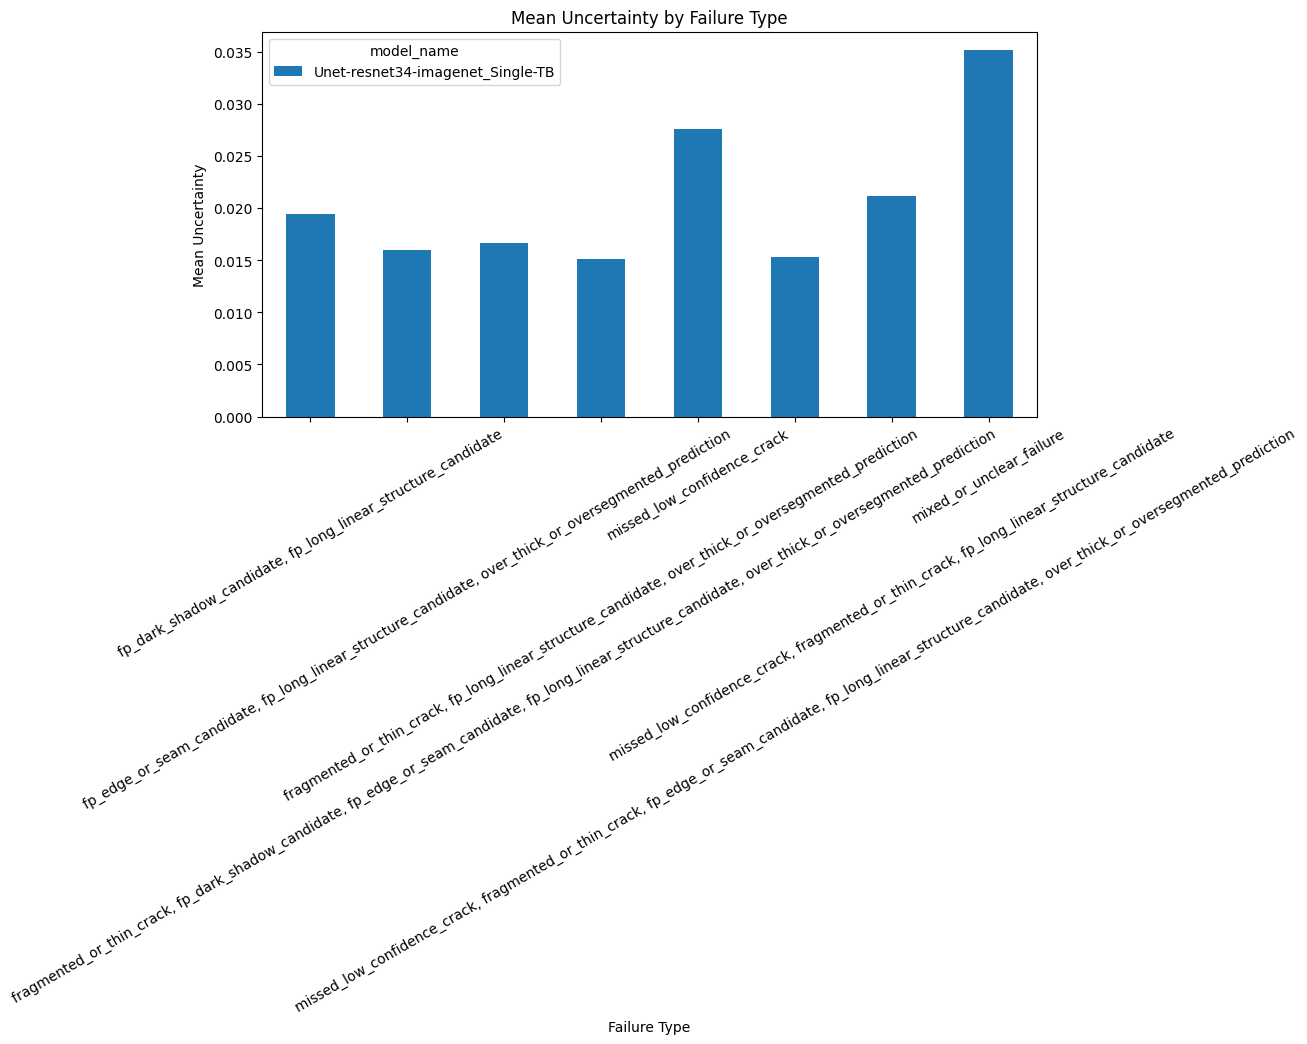

In [7]:
# Figure 2: failure-type uncertainty (top types by frequency)
top_types = df['failure_type'].value_counts().head(8).index
dfp = df[df['failure_type'].isin(top_types)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
if sns is not None:
    sns.boxplot(data=dfp, x='failure_type', y='mean_uncertainty', hue='model_name', ax=ax)
else:
    # fallback: grouped means only
    grp = dfp.groupby(['failure_type','model_name'])['mean_uncertainty'].mean().unstack(fill_value=np.nan)
    grp.plot(kind='bar', ax=ax)

ax.set_title('Mean Uncertainty by Failure Type')
ax.set_xlabel('Failure Type')
ax.set_ylabel('Mean Uncertainty')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
fig_path = OUT_DIR / 'fig_uncertainty_by_failure_type.png'
fig.savefig(fig_path, dpi=180)
print('Saved:', fig_path)
plt.show()
